In [1]:
import numpy as np
import pandas as pd
import torch
from torchvision import models, transforms
import cv2
import matplotlib.pyplot as plt
import PIL

import os

### Обученная CNN и датасет
https://www.kaggle.com/code/magokecol/pytorch-feature-maps-visualizer-snake-version/notebook

https://huggingface.co/datasets/ILSVRC/imagenet-1k


In [2]:
from datasets import load_dataset
ds = load_dataset("ILSVRC/imagenet-1k", streaming=True)

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

In [3]:
# VGG19 BN
model = models.vgg19_bn()
model.load_state_dict(torch.load('./vgg19_bn-c79401a0.pth'))
model.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256

In [4]:
# list cnn layers
layers = [layer for layer in model.children()]
print('Layers: {}'.format(len(layers)))
print('Layers[0]: {}'.format(len(layers[0])))

# global variable to work with GPU if possible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Layers: 3
Layers[0]: 53


### Захват активаций выбранного слоя

In [5]:
class SaveFeatures():
    def __init__(self, module, device=None):
        # we are going to hook some model's layer (module here)
        self.hook = module.register_forward_hook(self.hook_fn)
        self.device = device

    def hook_fn(self, module, input, output):
        # when the module.forward() is executed, here we intercept its
        # input and output. We are interested in the module's output.
        self.features = output.clone()
        if self.device is not None:
            self.features = self.features.to(device)
        self.features.requires_grad_(True)

    def close(self):
        # we must call this method to free memory resources
        self.hook.remove()

In [6]:
# (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
# (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
# (2): ReLU(inplace=True)
example_layer = layers[0][2]
activation = SaveFeatures(example_layer, device)
model(torch.rand(1, 3, 64, 64))
print(example_layer)
print(activation.features.shape)
activation.close()

ReLU(inplace=True)
torch.Size([1, 64, 64, 64])


### Визуализация карт признаков

Генерирует изображение (входные данные в модель), получаемое через максимизацию карты признаков (усредненное всех значений) для заданного фильтра на заданном слое

In [7]:
class FeatureMapVisualizer():
    def __init__(self, cnn, device, channels=3, layers_base=None, norm=None, denorm=None, save=None):
        self.model = cnn

        if layers_base is None:
            self.layers = self.model
        else:
            self.layers = layers_base
        
        self.channels = channels
        self.device = device

        mean = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32)
        std = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32)
            
        self.norm = norm
        self.denorm = denorm

        if norm is None:
            self.norm = transforms.Normalize(mean=mean.tolist(), std=std.tolist())

        if denorm is None:
            self.denorm = transforms.Normalize((-mean / std).tolist(), (1.0 / std).tolist())
            
        self.save = save

    def set_layers_base(self, layers):
        self.layers = layers
        
    def optimize_img(self, activations, filter, img, learning_rate, opt_steps, verbose):
        
        size = img.shape[1]
        img = torch.from_numpy(img.astype(np.float32).transpose(2,0,1))
        
        img = self.norm(img).double()
        img_input = img.clone().detach().reshape(1, self.channels, size, size).to(self.device).requires_grad_(True)
        optimizer = torch.optim.Adam([img_input], lr=learning_rate, weight_decay=1e-6)

        for n in range(opt_steps):
            optimizer.zero_grad()
            self.output = self.model(img_input)
            loss = -1 * activations.features[0, filter].mean()
            loss.backward()
            if verbose > 1:
                print('.', end='')
            optimizer.step()
        if verbose > 1:
            print()
        img = self.denorm(img_input.clone().detach()[0].type(torch.float32))
        img = img.cpu().numpy().transpose(1,2,0)
        return img
        

    def visualize(self, layer, filter, size=56, upscaling_steps=12, upscaling_factor=1.2, lr=0.1, opt_steps=20, blur=None, verbose=2):
        training = self.model.training
        self.model.eval()
        self.model = self.model.double().to(self.device)
        # generate random image
        img = np.uint8(np.random.uniform(100, 160, (size, size, self.channels)))/255
        # register hook
        activations = SaveFeatures(self.layers[layer], self.device)
        if verbose > 0:
            print('Processing filter {}...'.format(filter))

        for i in range(upscaling_steps):
            if verbose > 1:
                print('{:3d} x {:3d}'.format(size,size), end='')

            img = self.optimize_img(activations, filter, img, learning_rate=lr, opt_steps=opt_steps, verbose=verbose)

            if i < upscaling_steps-1:
                size = int(size*upscaling_factor)
                # scale image up
                img = cv2.resize(img, (size, size), interpolation = cv2.INTER_CUBIC)
                # blur image to reduce high frequency patterns
                if blur is not None: img = cv2.blur(img,(blur,blur))
            img = np.clip(img, 0, 1)

        if verbose > 0:
            print('preparing image...')
        activations.close()
        self.model.train(training)
        if self.save != None:
            self.save("layer_{:02d}_filter_{:03d}.jpg".format(layer, filter), img)
        return img
    
    # We return the mean of every activation value, but this could
    # be other metric based on convolutional output values.
    def get_activations(self, monitor, input, mean=True):

        training = self.model.training
        self.model.eval()
        self.model = self.model.double().to(self.device)

        activations = {}
        mean_acts = {}

        print('hooking layers {}'.format(monitor))
        for layer in monitor:
            activations[layer] = SaveFeatures(self.layers[layer], device=self.device)

        self.output = self.model(input.to(self.device))

        for layer in activations.keys():
            filters = activations[layer].features.size()[1]
            mean_acts[layer] = [activations[layer].features[0,i].mean().item() for i in range(filters)]

        print('unhooking layers.')        
        for layer in activations.keys():
            activations[layer].close()
            
        self.model.train(training)
        
        if mean:
            return mean_acts
        
        return activations

In [50]:
# Генерация изображения для фильтра 91 слоя 48
# Получается "лучшая" картинка для выбранного фильтра 

fmv = FeatureMapVisualizer(model, device, layers_base=layers[0], save=None)
    
feature_map_48_91_img = fmv.visualize(
                            layer=48, filter=91, size=56,
                            upscaling_steps=10, upscaling_factor=1.2, opt_steps=40, blur=3, verbose=2
                        )

Processing filter 91...
 56 x  56........................................
 67 x  67........................................
 80 x  80........................................
 96 x  96........................................
115 x 115........................................
138 x 138........................................
165 x 165........................................
198 x 198........................................
237 x 237........................................
284 x 284........................................
preparing image...


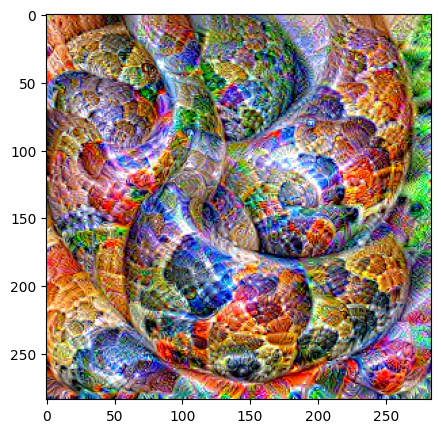

In [56]:
fig = plt.figure(figsize=(5,5))
plt.imshow(feature_map_48_91_img)
plt.show()

Полученное изображение предполагает быть "самым привлекательным" для выбранного фильтра (свёртки), т.е. воспроизводить на данном фильтре самую сильную активацию

### Предсказания по сгенерированному изображению

Найденное изображение было создано с помощью FeatureMapVisualizer. Интересное наблюдение состоит в том, что если обратить внимание на классы с наивысшей предсказанной вероятностью для этого изображения, то можно понять, что этот фильтр представляет собой некоторый "признак", связанный и с другими классами. Это изображение может быть своего рода представлением характеристик кластера.

Top 10 predicted classes:
- night snake, Hypsiglena torquata: 29.51011539057928
- hognose snake, puff adder, sand viper: 26.12454206647366
- king snake, kingsnake: 25.10749156580767
- ringneck snake, ring-necked snake, ring snake: 25.07674839977301
- thunder snake, worm snake, Carphophis amoenus: 22.85418170605221
- rock python, rock snake, Python sebae: 20.655300210934985
- sidewinder, horned rattlesnake, Crotalus cerastes: 20.539325706799115
- water snake: 19.66687306126861
- horned viper, cerastes, sand viper, horned asp, Cerastes cornutus: 17.829088213840716
- boa constrictor, Constrictor constrictor: 17.512067722662067
torch.Size([14, 14])


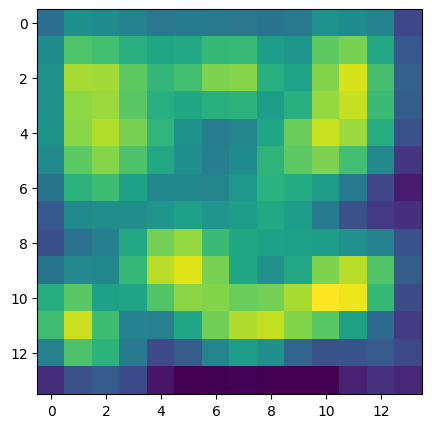

In [57]:
mean = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32)
std = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32)

normalize = transforms.Normalize(mean=mean.tolist(), std=std.tolist())
denormalize = transforms.Normalize((-mean / std).tolist(), (1.0 / std).tolist())

img2tensor = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor(), normalize])

class_labels = ds['train'].features['label'].names

def top(k, output, labels):
    values, indices = torch.topk(output, k, 1)
    values, indices = values[0].tolist(), indices[0].tolist()
    print('Top {} predicted classes:'.format(k))
    for i, idx in enumerate(indices):
        print('- {}: {}'.format(labels[idx], values[i]))

activation = SaveFeatures(layers[0][48], device=device)

input = img2tensor(PIL.Image.fromarray(np.uint8(feature_map_48_91_img*255))).unsqueeze(0).double()
output = model(input.to(device))

top(10, output, class_labels)

print(activation.features[0,91].shape)
fig = plt.figure(figsize=(5,5))
plt.imshow(activation.features[0,91].detach().cpu().numpy())
plt.show()
activation.close()

### Пример с реальными данными

In [75]:
ds_iter = iter(ds['train'])
sample = next(ds_iter)
while sample['label'] != ds['train'].features['label'].names.index('night snake, Hypsiglena torquata'):
    sample = next(ds_iter)

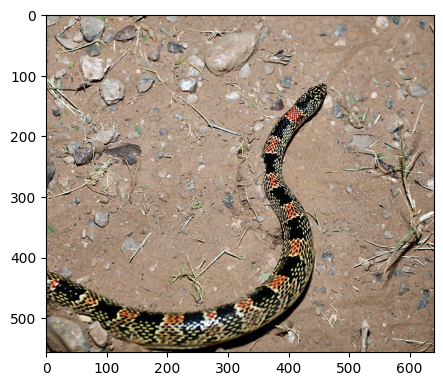

In [76]:
fig = plt.figure(figsize=(5,5))
plt.imshow(sample['image'])
plt.show()

Top 10 predicted classes:
- king snake, kingsnake: 22.31758364663368
- night snake, Hypsiglena torquata: 21.29212635040476
- water snake: 21.018108862697698
- hognose snake, puff adder, sand viper: 19.665485475732783
- ringneck snake, ring-necked snake, ring snake: 19.605060289111073
- sea snake: 17.438084094159887
- thunder snake, worm snake, Carphophis amoenus: 17.212070275321825
- diamondback, diamondback rattlesnake, Crotalus adamanteus: 16.801348037697306
- Indian cobra, Naja naja: 16.622356470396365
- sidewinder, horned rattlesnake, Crotalus cerastes: 16.326982094313724
torch.Size([14, 14])


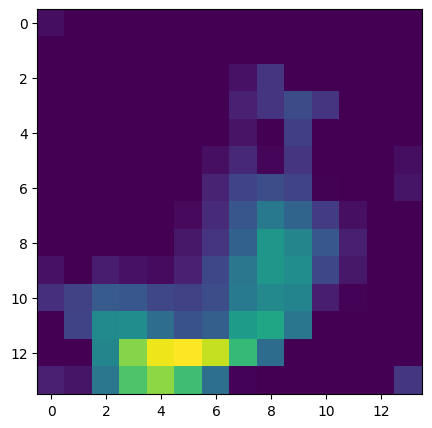

In [77]:
activation = SaveFeatures(layers[0][48], device=device)

input = img2tensor(sample['image']).unsqueeze(0).double()
output = model(input.to(device))

top(10, output, class_labels)

print(activation.features[0,91].shape)
fig = plt.figure(figsize=(5,5))
plt.imshow(activation.features[0,91].detach().cpu().numpy())
plt.show()
activation.close()

Мы могли бы выбрать по 3 лучших фильтра на каждом слое (на основе их активаций) для разных змей, а затем проверить, какие фильтры являются общими для изображений змей, а какие нет. Исходя из этой идеи:

* мы могли бы находить общие фильтры для каждого класса;

* мы могли бы выявлять связанные, но разные классы на основе общих фильтров, присутствующих у них;

* мы могли бы задавать имена кластерам фильтров, то есть создать своего рода языковое представление;

мы могли бы использовать эту информацию, чтобы "редактировать" CNN для выполнения других задач. Например, если мы хотим создать модель, способную различать только два класса, например лягушек и машины, то могли бы обнаружить, что в этих сетях есть только 30 важных фильтров, активирующихся на лягушках, и ещё 20 — на машинах, а затем использовать их для построения новой модели. А может быть, мы бы выяснили, что лучше применить transfer learning, чтобы не тратить время зря :D

#### Графики активаций на каждом блоке

hooking layers [2, 5, 9, 12, 16, 19, 22, 25, 29, 32, 35, 38, 42, 45, 48, 51]
unhooking layers.
Generating visualization for filters activations per layer................tight_layout...


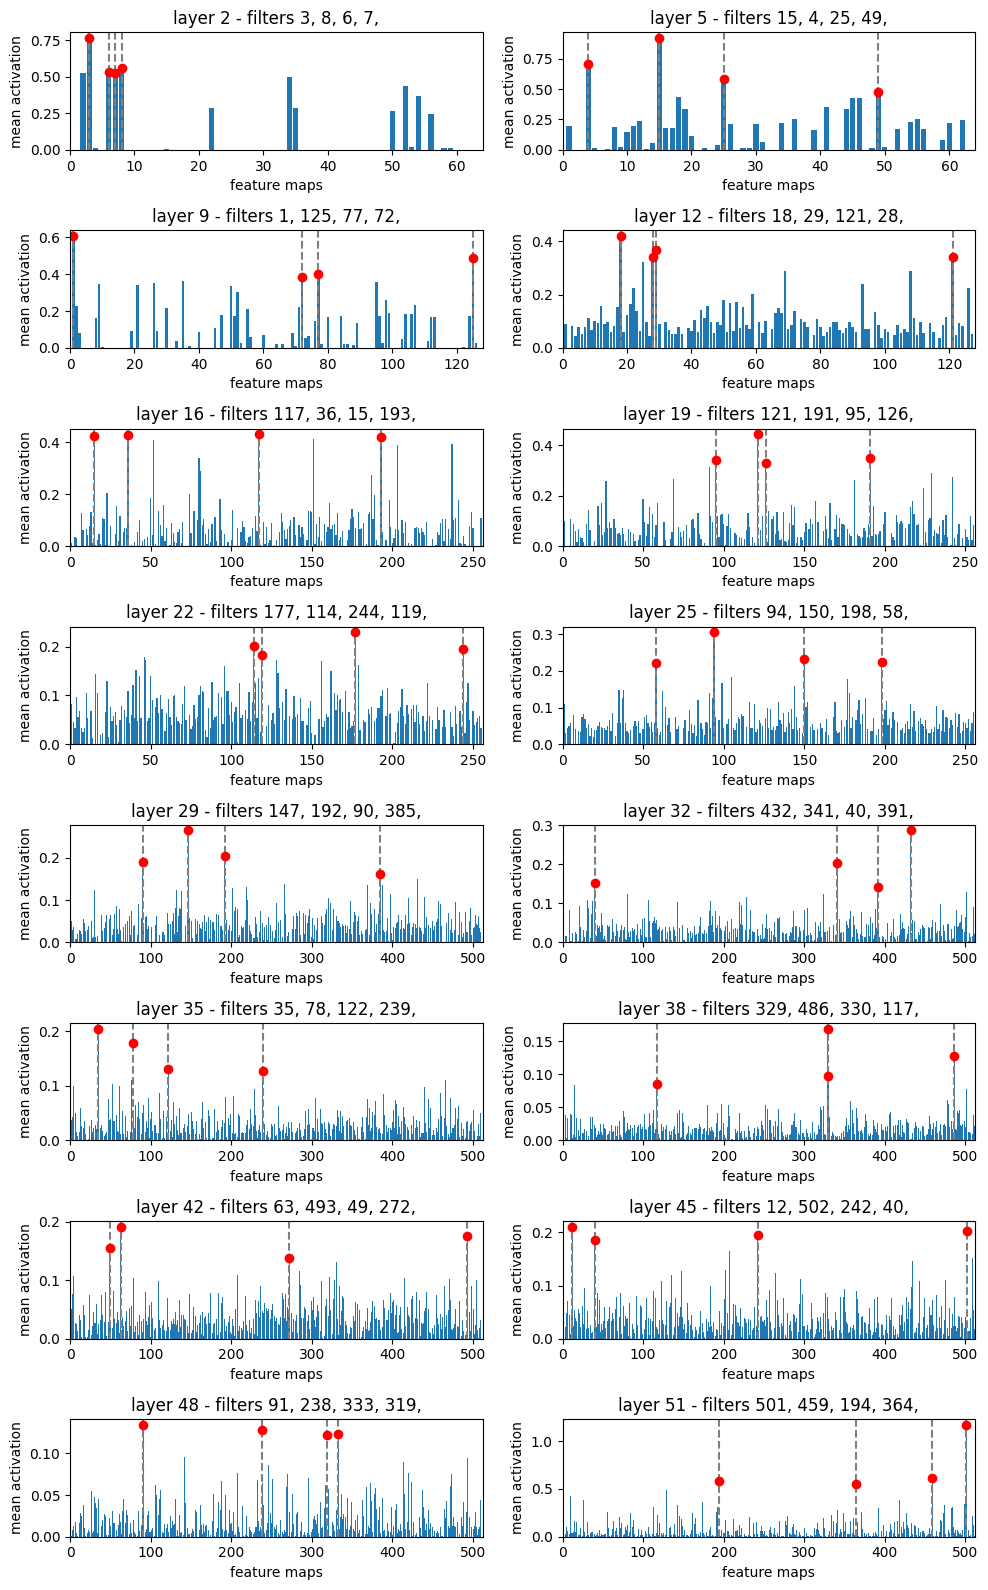

In [86]:
# transform image to tensor and generate input for the model
input = img2tensor(sample['image']).unsqueeze(0).double()

# Каждый блок заканчивается ReLU
monitor = [i for i, layer in enumerate(layers[0]) if isinstance(layer, torch.nn.ReLU)]

# get activations 
mean_acts = fmv.get_activations(monitor, input)

top_filters = {}
n = len(mean_acts)
TOP = 4
# we are monitoring 16 layers
rows, cols = 8,2
fig = plt.figure(figsize=(cols*5, rows*2))
print('Generating visualization for filters activations per layer', end='')
for i,k in enumerate(mean_acts.keys()):
    print('.', end='')
    ax = plt.subplot(rows, cols, i+1)
    top_filters[k] = sorted(range(len(mean_acts[k])), key=lambda idx: mean_acts[k][idx], reverse=True)[:TOP]
    for filter in top_filters[k]:
        plt.axvline(x=filter, color='grey', linestyle='--')
    act = plt.bar(list(range(len(mean_acts[k]))), mean_acts[k])
    ax = act[0].axes
    ax.set_xlim(0,len(mean_acts[k]))
    ax.plot(top_filters[k], [mean_acts[k][f] for f in top_filters[k]], 'ro')
    ax.set_xlabel("feature maps")
    ax.set_ylabel("mean activation")
    f_desc = ''
    for f in top_filters[k]:
        f_desc += ' ' + str(f) + ','
    ax.set_title('layer {} - filters{}'.format(k, f_desc))
print('tight_layout...')
plt.tight_layout()

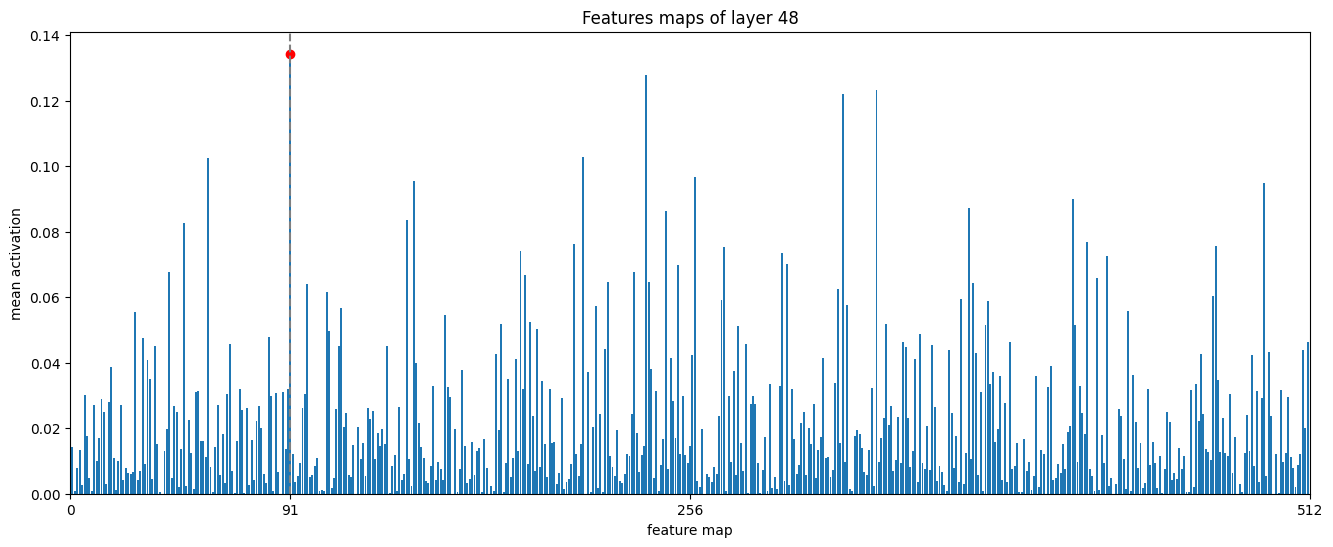

In [87]:
def show_filters(mean_act, filter, layer=None):
    filters = len(mean_act)
    plt.figure(figsize=(16,6))
    extraticks=[filter]
    act = plt.bar(list(range(filters)), mean_act)
    ax = act[0].axes
    ax.set_xticks([0,int(filters/2),filters] + extraticks)
    ax.set_xlim(0,filters)
    ax.plot(filter, mean_act[filter], 'ro')
    plt.axvline(x=filter, color='grey', linestyle='--')
    ax.set_xlabel("feature map")
    ax.set_ylabel("mean activation")
    if layer is not None:
        ax.set_title('Features maps of layer {}'.format(layer))
    plt.show()

show_filters(mean_acts[48], 91, '48')

#### Визуализация лучших входов по сильнейшим фильтрам

In [ ]:
fms = {}
fmv = FeatureMapVisualizer(model, device, layers_base=layers[0])
for layer in top_filters.keys():
    filters = top_filters[layer]
    fms[layer] = []
    for filter in filters:
        fms[layer].append(fmv.visualize(
            layer=layer, filter=filter,
            size=56, upscaling_steps=10, upscaling_factor=1.2,
            lr=0.1, opt_steps=20, blur=3, verbose=2))

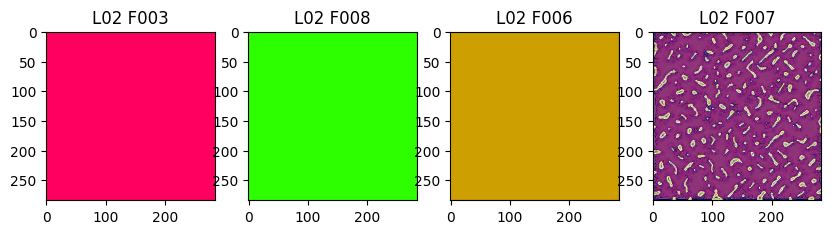

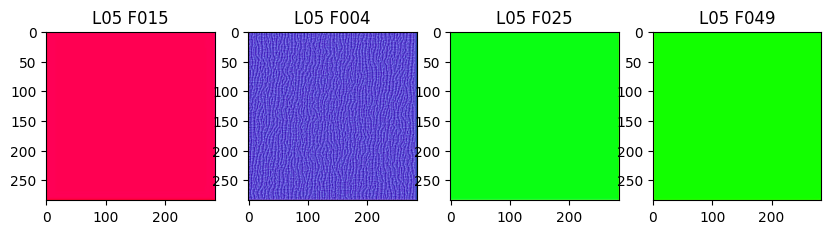

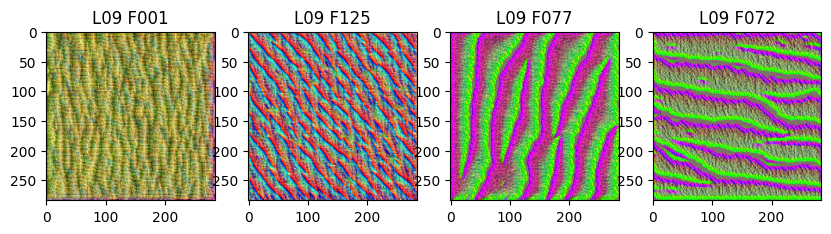

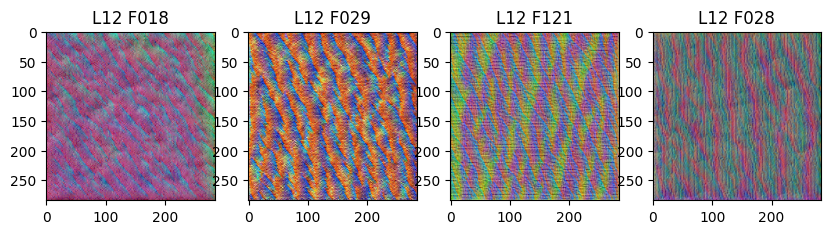

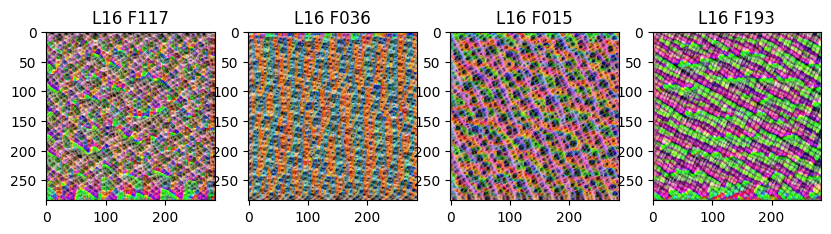

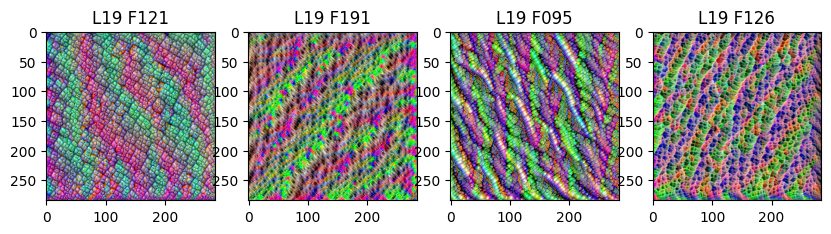

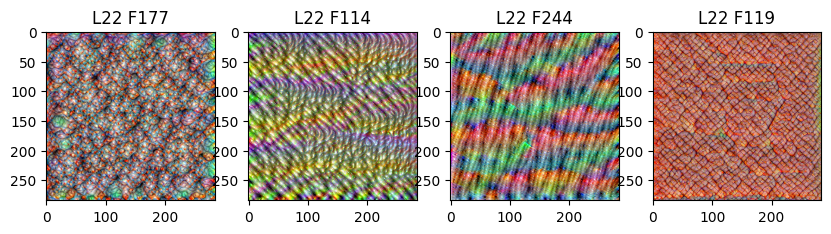

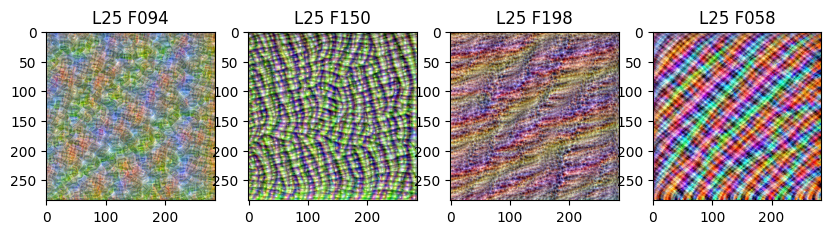

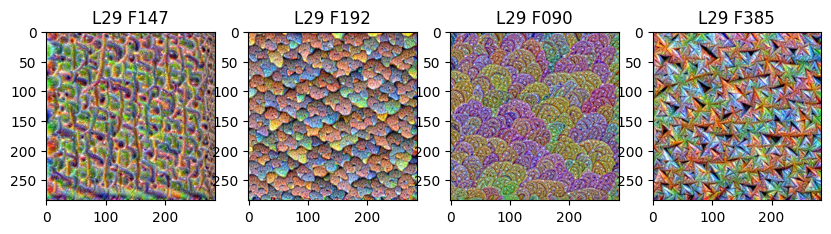

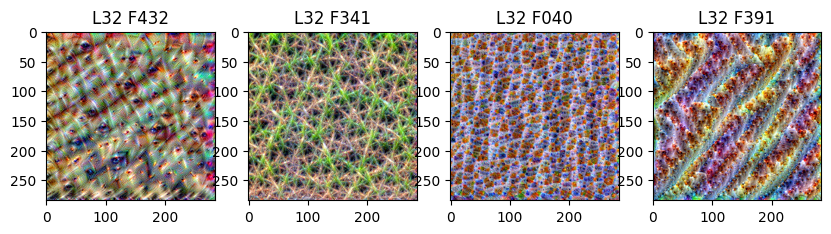

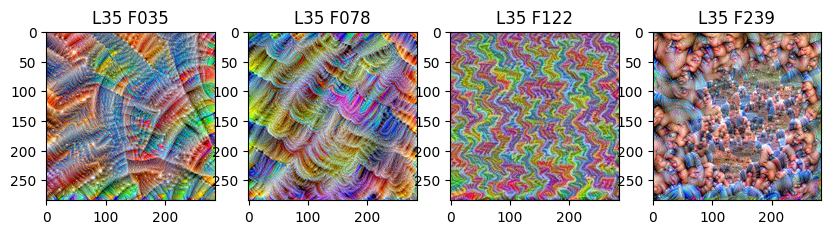

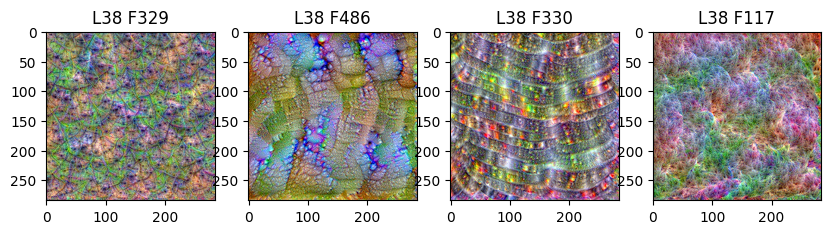

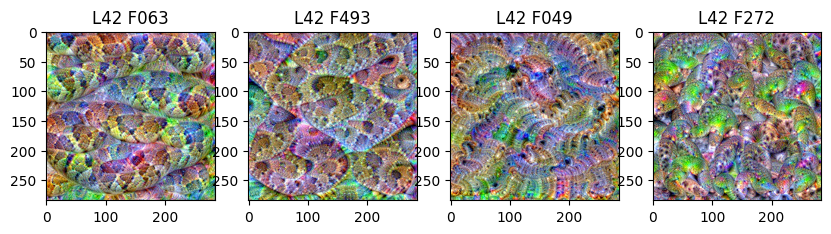

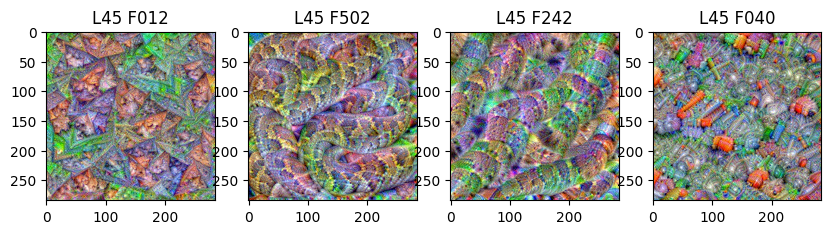

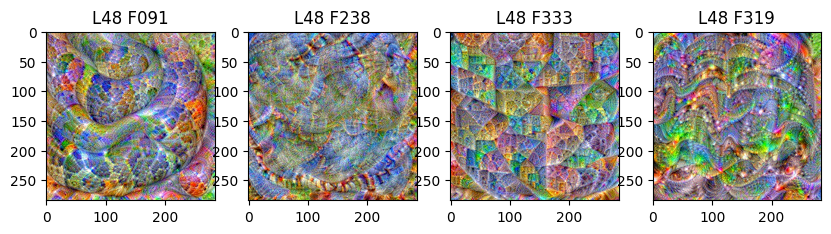

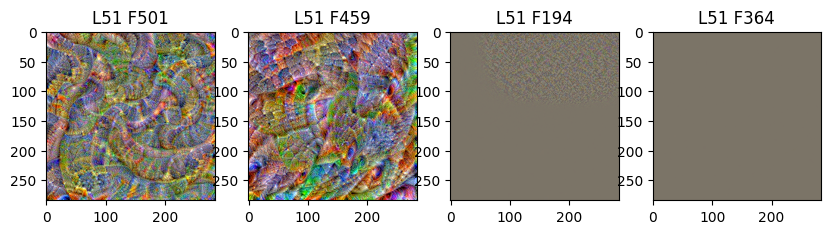

In [91]:
for layer in fms.keys():
    filters = top_filters[layer]
    fig = plt.figure(figsize=(10,5))    
    for i in range(len(filters)):
        ax = plt.subplot(1,len(filters), i+1)
        ax.imshow(fms[layer][i])
        ax.set_title('L{:02d} F{:03d}'.format(layer, filters[i]))
    plt.show()

## Задачи

1. Взять вашу модель, обученную в задачах *Lab3_arcface* на датасете https://github.com/phelber/EuroSAT?tab=readme-ov-file
2. Выбрать любой фильтр на любом из глубоких слоев вашей модели, сгенерировать "самое привлекательное" изображение через максимизацию активации
3. Повторить пример с графиками активаций и генерацией на все блоки (для глубоких сетей можно взять 8-12 слоев) для любого изображения класса "River". Повторить для класса "Highway".